In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import time

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {device}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_properties(0).name}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch version: 2.9.1+cu128
Device         : cuda
GPU            : NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU
GPU memory     : 8.5 GB


In [2]:
# load data

# features and targets
X_norm       = np.load('data/ds4x_X_norm.npy')
R            = np.load('data/ds4x_spec7.npy')
E            = np.load('data/anc_endmembers5x7.npy')
valid_mask   = np.load('data/ds4x_specvalid_mask.npy')

# spatial Laplacians
L_elev   = sp.load_npz('data/ds4x_L_elev.npz')
L_aspect = sp.load_npz('data/ds4x_L_aspect.npz')
L_ddem   = sp.load_npz('data/ds4x_L_ddem.npz')

# spectral Laplacian
L_band = np.load('data/ds4x_L_band.npy')

# anchor info
E_df = pd.read_csv('data/anc_endmems5x7_named.csv')

print(f'X_norm     : {X_norm.shape}   dtype={X_norm.dtype}')
print(f'R          : {R.shape}   dtype={R.dtype}')
print(f'E          : {E.shape}   dtype={E.dtype}')
print(f'valid_mask : {valid_mask.shape}  dtype={valid_mask.dtype}')
print(f'L_elev     : {L_elev.shape}  nnz={L_elev.nnz:,}')
print(f'L_aspect   : {L_aspect.shape}  nnz={L_aspect.nnz:,}')
print(f'L_ddem     : {L_ddem.shape}  nnz={L_ddem.nnz:,}')
print(f'L_band     : {L_band.shape}')
print()
print('anchor endmembers:')
print(E_df[['anchor_id', 'name']].to_string())

X_norm     : (124720, 12)   dtype=float32
R          : (124720, 7)   dtype=float32
E          : (5, 7)   dtype=float32
valid_mask : (124720,)  dtype=bool
L_elev     : (124720, 124720)  nnz=1,117,088
L_aspect   : (124720, 124720)  nnz=1,117,096
L_ddem     : (124720, 124720)  nnz=1,113,956
L_band     : (6, 6)

anchor endmembers:
   anchor_id                                      name
0         18             turbid glacier outflow (gray)
1         26                     gray outwash sediment
2         13                    north slope vegetation
3          2                        south slope gravel
4          5  post-glacial settling (north slope edge)


In [3]:
# convert to torch tensors

def scipy_csr_to_torch_sparse(L, device):
    L = L.astype(np.float32)
    crow_indices = torch.tensor(L.indptr,  dtype=torch.int32)
    col_indices  = torch.tensor(L.indices, dtype=torch.int32)
    values       = torch.tensor(L.data,    dtype=torch.float32)
    return torch.sparse_csr_tensor(
        crow_indices, col_indices, values,
        size=L.shape, dtype=torch.float32
    ).to(device)

In [4]:
# Dense tensors
X      = torch.tensor(X_norm, dtype=torch.float32, device=device)
R_tens = torch.tensor(R,      dtype=torch.float32, device=device)
E_tens = torch.tensor(E,      dtype=torch.float32, device=device)
mask   = torch.tensor(valid_mask, dtype=torch.bool, device=device)
L_band_tens = torch.tensor(L_band, dtype=torch.float32, device=device)
print('dense tensors built')

dense tensors built


In [5]:
# Sparse Laplacians
print('Converting sparse Laplacians to torch...')
L_elev_t   = scipy_csr_to_torch_sparse(L_elev,   device)
L_aspect_t = scipy_csr_to_torch_sparse(L_aspect, device)
L_ddem_t   = scipy_csr_to_torch_sparse(L_ddem,   device)
print('sparse Laplacians built')

Converting sparse Laplacians to torch...
sparse Laplacians built


/tmp/ipykernel_56823/459447783.py:8: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(


In [6]:
print(f'X          : {X.shape}  {X.device}')
print(f'R_tens     : {R_tens.shape}')
print(f'E_tens     : {E_tens.shape}')
print(f'mask       : {mask.shape}  valid={mask.sum().item():,}')
print(f'L_band     : {L_band_tens.shape}')
print(f'L_elev_t   : {L_elev_t.shape}  {L_elev_t.device}')
print(f'L_aspect_t : {L_aspect_t.shape}')
print(f'L_ddem_t   : {L_ddem_t.shape}')
print()

mem_used = torch.cuda.memory_allocated() / 1e9
mem_free = torch.cuda.mem_get_info()[0] / 1e9
print(f'GPU allocated: {mem_used:.2f} GB')
print(f'GPU free     : {mem_free:.2f} GB')

X          : torch.Size([124720, 12])  cuda:0
R_tens     : torch.Size([124720, 7])
E_tens     : torch.Size([5, 7])
mask       : torch.Size([124720])  valid=124,720
L_band     : torch.Size([6, 6])
L_elev_t   : torch.Size([124720, 124720])  cuda:0
L_aspect_t : torch.Size([124720, 124720])
L_ddem_t   : torch.Size([124720, 124720])

GPU allocated: 0.04 GB
GPU free     : 7.22 GB


In [7]:
### architecture classes ###

In [8]:
class CPDTensorLayer(nn.Module):
    """
    rank-R canonical polyadic decomposition (CPD) tensor layer
    mapping (spectral + topo) -> hidden

    Input:
        x_i ∈ ℝ^{D_in} split into:
            s_i ∈ ℝ^{D_s} (spectral, first D_s features (here 5 bands))
            t_i ∈ ℝ^{D_t} (topographic+aux, remaining features (here 6 topo + 2 aux bands)

    Weight tensor:
        W ∈ ℝ^{D_s x D_t x D_out} in rank-R CPD format:
        W = Σ_r (u_r^(1) ⊗ u_r^(2) ⊗ u_r^(3))

        where ⊗ := outer product
        and u_r^(*) is the r-th decomposition vector of U(*)

    Factor matrices:
        U1 ∈ ℝ^{D_s  x R}   spectral mode -- regularized by L_band
        U2 ∈ ℝ^{D_t  x R}   topographic mode 
        U3 ∈ ℝ^{D_out  x R} output mode

        'mode' in the tensor sense
        R (hyperparameter) CPD rank: 
            number of rank-1 terms in the decomposition
            controls how expressive the weight tensor is
        D_out (hyperparameter) output dimension of the tensor layer:
            determines dimensionality of the hidden space
            that passes to the attention layer
        

    Forward pass -- (tensor) efficient: never builds full W:
        h_i = Σ_r (s_i · u_r^(1)) * (t_i · u_r^(2)) * u_r^(3)
            = U3 · ((U1ᵀ s_i) * (U2ᵀ t_i))
            outputs a vector of length D_out
            note: 1st line '·' = vector inner product
                           '*' = scalar multiplication
                  2nd line '.' = matrix-vector product
                           '*' = element-wise vector multiplication
        
    """
    def __init__(self, D_s, D_t, D_out, R):
        super().__init__()
        self.D_s = D_s
        self.D_t = D_t
        self.R   = R
        self.U1  = nn.Parameter(torch.empty(D_s, R))
        self.U2  = nn.Parameter(torch.empty(D_t, R))
        self.U3  = nn.Parameter(torch.empty(D_out, R))
        nn.init.xavier_normal_(self.U1)
        nn.init.xavier_normal_(self.U2)
        nn.init.xavier_normal_(self.U3)
        self.norm = nn.LayerNorm(D_out)

    def forward(self, x):
        s     = x[:, :self.D_s]
        t     = x[:, self.D_s:]
        alpha = s @ self.U1
        beta  = t @ self.U2
        gamma = alpha * beta
        h     = gamma @ self.U3.T
        return torch.relu(self.norm(h))

    def band_regularization(self, L_band):
        # L_band is 6x6, U1 is (D_s=7, R)
        # regularize only bands 0-5 (blue-panc, exclude lwir)
        U1_6 = self.U1[:6, :]
        return torch.trace(U1_6.T @ L_band @ U1_6)
print('defined CPDTensorLayer')

defined CPDTensorLayer


In [9]:
class CrossModalAttention(nn.Module):
    """
    cross-modal attention between the CPD hidden representation
    and the raw input features

    Query   : from CPD hidden h ∈ ℝ^{D_hidden}
    Key     : from raw input  x ∈ ℝ^{D_in}
    Value   : from raw input  x ∈ ℝ^{D_in}

    Learns which input features are most informative
        given the joint spectral-topographic representation.
    Residual connection added for training stability
    """
    def __init__(self, D_hidden, D_in, D_attn):
        super().__init__()
        self.scale = D_attn ** -0.5
        self.W_Q   = nn.Linear(D_hidden, D_attn, bias=False)
        self.W_K   = nn.Linear(D_in,     D_attn, bias=False)
        self.W_V   = nn.Linear(D_in,     D_attn, bias=False)
        self.W_O   = nn.Linear(D_attn,   D_hidden, bias=False)
        self.norm  = nn.LayerNorm(D_hidden)

    def forward(self, h, x):
        Q     = self.W_Q(h)
        K     = self.W_K(x)
        V     = self.W_V(x)
        attn  = torch.sum(Q * K, dim=1, keepdim=True) * self.scale
        attn  = torch.sigmoid(attn)
        out   = self.W_O(attn * V)
        return self.norm(h + out)
print('CrossModalAttention defined')

CrossModalAttention defined


In [10]:
class GRANU(nn.Module):
    """
    Graph Regularized Anchor Node Unmixer

    CPD tensor layer maps (spectral x topo) -> hidden
    Cross-modal attn refines using raw input
    Softmax membership (anchor) head -> simplex-constrained [0,1]^k

    ### add external loss notes ###
    """
    def __init__(self, D_s=7, D_t=5, D_out=32, R=8, D_attn=16, k=5):
        super().__init__()
        self.D_s = D_s
        self.D_t = D_t
        self.cpd = CPDTensorLayer(D_s, D_t, D_out, R)
        self.attn = CrossModalAttention(D_out, D_s + D_t, D_attn)
        self.head = nn.Sequential(
            nn.Linear(D_out, k),
            nn.Softmax(dim=1)  # sum-to-one constraint
        )

    def forward(self, x):
        h = self.cpd(x)
        h = self.attn(h, x)
        return self.head(h)

    def band_regularization(self, L_band):
        return self.cpd.band_regularization(L_band)
print('GRANU defined')        

GRANU defined


In [19]:
# instantiate
model = GRANU(D_s=7, D_t=5, D_out=32, R=8, D_attn=16, k=5).to(device)
print('model instantiated')

model instantiated


In [12]:
# show parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'GRANU parameters: {total_params:,}')
print()
for name, p in model.named_parameters():
    print(f'  {name:<30} {str(p.shape):<25} {p.numel():>6}')

GRANU parameters: 2,053

  cpd.U1                         torch.Size([7, 8])            56
  cpd.U2                         torch.Size([5, 8])            40
  cpd.U3                         torch.Size([32, 8])          256
  cpd.norm.weight                torch.Size([32])              32
  cpd.norm.bias                  torch.Size([32])              32
  attn.W_Q.weight                torch.Size([16, 32])         512
  attn.W_K.weight                torch.Size([16, 12])         192
  attn.W_V.weight                torch.Size([16, 12])         192
  attn.W_O.weight                torch.Size([32, 16])         512
  attn.norm.weight               torch.Size([32])              32
  attn.norm.bias                 torch.Size([32])              32
  head.0.weight                  torch.Size([5, 32])          160
  head.0.bias                    torch.Size([5])                5


In [13]:
# define loss function
def granu_loss(A, R_tens, E_tens, mask,
               L_elev_t, L_aspect_t, L_ddem_t,
               L_band_tens, model,
               lam_elev, lam_aspect, lam_ddem, lam_band):
    """
    GRANU loss function

    Terms:
        1. Spectral reconstruction : ||R_valid - A_valid @ E_6band||^2_F / N_valid
        2. Elevation smoothness    : lam_elev   * tr((A^T L_elev  A) / N
        3. Aspect smoothness       : lam_aspect * tr(A^T L_aspect A) / N
        4. dDEM smoothness         : lam_ddem   * tr(A^T L_ddem   A) / N
        5. Band factor smoothness  : lam_band   * tr(U1[:6]^T L_band U1[:6])

    Notes:
        - Reconstruction uses 6 bands -- blue-panc -- exclude LWIR
        - Softmax ensures A rows sum to 1
        - L_band regularization band 1-6 only (index 0-5) no LWIR
    """

    # --- 1. reconstruction loss (bands 1-6 (index 0-5) only, no LWIR) ---
    # softmax A sums to 1 so A @ E is in reflectance space directly
    A_valid = A[mask]             # (N_valid, k)
    R_valid = R_tens[mask, :6]    # (N_valid, 6) # blue-panc
    E_6band = E_tens[:, :6]       # (k, 6)
    R_pred  = A_valid @ E_6band    # (N_valid, 6)

    loss_recon = torch.sum((R_valid - R_pred)**2) / mask.sum()

    # --- 2. spatial smoothness ---
    LA_elev   = torch.sparse.mm(L_elev_t,   A)
    LA_aspect = torch.sparse.mm(L_aspect_t, A)
    LA_ddem   = torch.sparse.mm(L_ddem_t,   A)

    loss_elev   = torch.sum(A * LA_elev)   / A.shape[0]
    loss_aspect = torch.sum(A * LA_aspect) / A.shape[0]
    loss_ddem   = torch.sum(A * LA_ddem)   / A.shape[0]

    loss_spatial = (lam_elev    * loss_elev +
                    lam_aspect  * loss_aspect +
                    lam_ddem    * loss_ddem)

    # --- 3. band factor smoothness ---
    loss_band = lam_band * model.band_regularization(L_band_tens)

    # --- Total Loss ---
    loss_total = loss_recon + loss_spatial + loss_band

    return loss_total, loss_recon, loss_spatial, loss_band
print('granu_loss updated -- reconstruction uses bands 0-5 only')

granu_loss updated -- reconstruction uses bands 0-5 only


In [17]:
## empirical lambda calibration ##
model.eval()
with torch.no_grad():
    A_test = model(X)

    # reconstruction:
    R_pred_6    = A_test[mask] @ E_tens[:, :6]
    raw_recon = torch.sum((R_tens[mask, :6] - R_pred_6)**2).item() / mask.sum().item()

    # spatial
    LA_elev   = torch.sparse.mm(L_elev_t,   A_test)
    LA_aspect = torch.sparse.mm(L_aspect_t, A_test)
    LA_ddem   = torch.sparse.mm(L_ddem_t,   A_test)

    raw_elev   = torch.sum(A_test * LA_elev).item()   / A_test.shape[0]
    raw_aspect = torch.sum(A_test * LA_aspect).item() / A_test.shape[0]
    raw_ddem   = torch.sum(A_test * LA_ddem).item()   / A_test.shape[0]

    # band
    raw_band = model.band_regularization(L_band_tens).item()

print('Unweighted loss term magnitudes:')
print(f'  recon          : {raw_recon:.6f}')
print(f'  spatial_elev   : {raw_elev:.6f}')
print(f'  spatial_aspect : {raw_aspect:.6f}')
print(f'  spatial_ddem   : {raw_ddem:.6f}')
print(f'  band           : {raw_band:.6f}')
print()
print('Suggested lambdas to balance with recon:')
print(f'  lam_elev   ~ {raw_recon/raw_elev:.4f}')
print(f'  lam_aspect ~ {raw_recon/raw_aspect:.4f}')
print(f'  lam_ddem   ~ {raw_recon/raw_ddem:.4f}')
print(f'  lam_band   ~ {raw_recon/raw_band:.6f}')

Unweighted loss term magnitudes:
  recon          : 0.117290
  spatial_elev   : 0.016560
  spatial_aspect : 0.015510
  spatial_ddem   : 0.017577
  band           : 5.610213

Suggested lambdas to balance with recon:
  lam_elev   ~ 7.0829
  lam_aspect ~ 7.5620
  lam_ddem   ~ 6.6730
  lam_band   ~ 0.020906


In [20]:
## using the above ##
LAM_ELEV   = 7.0
LAM_ASPECT = 7.5
LAM_DDEM   = 6.5
LAM_BAND   = 0.02

In [24]:
ATTEMPT = 1
N_EPOCHS      = 100
label = "granu_chkp_ep" + str(N_EPOCHS) + "atp" + str(ATTEMPT) + ".pt"
print('data/'+label)

data/granu_chkp_ep100atp1.pt


In [36]:
### Training Loop ###

LEARNING_RATE = 1e-3
N_EPOCHS      = 300
LOG_EVERY     = 20

ATTEMPT = 2 # change to save different training attempts
label = "granu_chkp_ep" + str(N_EPOCHS) + "atp" + str(ATTEMPT) + ".pt"

### fresh model if necessary ###

# optimizer
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

history = {'total': [], 'recon': [], 'spatial': [], 'band' : []}

print('GRANU Training')
print(f'  Epochs        : {N_EPOCHS}')
print(f'  Learning rate : {LEARNING_RATE}')
print(f'  lam_elev      : {LAM_ELEV}')
print(f'  lam_aspect    : {LAM_ASPECT}')
print(f'  lam_ddem      : {LAM_DDEM}')
print(f'  lam_band      : {LAM_BAND}')
print(f'  N nodes       : {X.shape[0]:,}')
print(f'  k anchors     : {E_tens.shape[0]}')
print()

t_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    A = model(X)

    loss_total, loss_recon, loss_spatial, loss_band = granu_loss(
        A, R_tens, E_tens, mask,
        L_elev_t, L_aspect_t, L_ddem_t,
        L_band_tens, model,
        LAM_ELEV, LAM_ASPECT, LAM_DDEM, LAM_BAND
    )

    loss_total.backward()
    optimizer.step()

    history['total'].append(loss_total.item())
    history['recon'].append(loss_recon.item())
    history['spatial'].append(loss_spatial.item())
    history['band'].append(loss_band.item())

    if epoch % LOG_EVERY == 0 or epoch == 1:
        elapsed = time.time() - t_start
        print(f'Epoch {epoch:>4d}/{N_EPOCHS}  '
              f'total={loss_total.item():.6f}  '
              f'recon={loss_recon.item():.6f}  '
              f'spatial={loss_spatial.item():.6f}  '
              f'band={loss_band.item():.6f}  '
              f'({elapsed:.1f}s)')

print()
print(f'Training complete in {time.time()-t_start:.1f}s')

# Save checkpoint
torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'     : N_EPOCHS,
    'history'   : history,
    'hyperparams': {
        'D_s': 7, 'D_t': 5, 'D_out': 32,
        'R': 8, 'D_attn': 16, 'k': 5,
        'lr': LEARNING_RATE,
        'lam_elev': LAM_ELEV, 'lam_aspect': LAM_ASPECT,
        'lam_ddem': LAM_DDEM, 'lam_band': LAM_BAND
    }
}, 'data/'+label)

print('saved ' + label)

GRANU Training
  Epochs        : 300
  Learning rate : 0.001
  lam_elev      : 20.0
  lam_aspect    : 25.0
  lam_ddem      : 15.0
  lam_band      : 0.02
  N nodes       : 124,720
  k anchors     : 5

Epoch    1/300  total=1.069665  recon=0.106393  spatial=0.790315  band=0.172958  (0.2s)
Epoch   20/300  total=0.561068  recon=0.097448  spatial=0.295570  band=0.168050  (0.5s)
Epoch   40/300  total=0.442763  recon=0.090461  spatial=0.193573  band=0.158729  (0.8s)
Epoch   60/300  total=0.390810  recon=0.086108  spatial=0.156260  band=0.148442  (1.2s)
Epoch   80/300  total=0.361176  recon=0.082499  spatial=0.140408  band=0.138270  (1.5s)
Epoch  100/300  total=0.340611  recon=0.079693  spatial=0.132343  band=0.128575  (1.8s)
Epoch  120/300  total=0.324596  recon=0.077756  spatial=0.127358  band=0.119482  (2.1s)
Epoch  140/300  total=0.311280  recon=0.076131  spatial=0.124146  band=0.111003  (2.4s)
Epoch  160/300  total=0.299824  recon=0.074738  spatial=0.121971  band=0.103115  (2.7s)
Epoch  1

In [38]:
# Continue training from current state -- do NOT reinitialize model
N_EPOCHS_2    = 1000
LOG_EVERY     = 100

t_start = time.time()

for epoch in range(1, N_EPOCHS_2 + 1):
    model.train()
    optimizer.zero_grad()

    A = model(X)

    loss_total, loss_recon, loss_spatial, loss_band = granu_loss(
        A, R_tens, E_tens, mask,
        L_elev_t, L_aspect_t, L_ddem_t,
        L_band_tens, model,
        LAM_ELEV, LAM_ASPECT, LAM_DDEM, LAM_BAND
    )

    loss_total.backward()
    optimizer.step()

    history['total'].append(loss_total.item())
    history['recon'].append(loss_recon.item())
    history['spatial'].append(loss_spatial.item())
    history['band'].append(loss_band.item())

    if epoch % LOG_EVERY == 0 or epoch == 1:
        elapsed = time.time() - t_start
        print(f'Epoch {epoch:>5d}/{N_EPOCHS_2}  '
              f'total={loss_total.item():.6f}  '
              f'recon={loss_recon.item():.6f}  '
              f'spatial={loss_spatial.item():.6f}  '
              f'band={loss_band.item():.6f}  '
              f'({elapsed:.1f}s)')

print(f'\nTraining complete in {time.time()-t_start:.1f}s')

torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : 300 + N_EPOCHS_2,
    'history'             : history,
    'hyperparams': {
        'D_s': 7, 'D_t': 5, 'D_out': 32,
        'R': 8, 'D_attn': 16, 'k': 5,
        'lr': 1e-3,
        'lam_elev': LAM_ELEV, 'lam_aspect': LAM_ASPECT,
        'lam_ddem': LAM_DDEM, 'lam_band': LAM_BAND
    }
}, 'data/granu_chkp_ep1300atp2.pt')

print('Saved granu_chkp_ep1300atp2.pt')

Epoch     1/1000  total=0.247240  recon=0.069246  spatial=0.116909  band=0.061085  (0.2s)
Epoch   100/1000  total=0.225849  recon=0.067754  spatial=0.116166  band=0.041928  (1.6s)
Epoch   200/1000  total=0.211098  recon=0.067102  spatial=0.115673  band=0.028324  (3.0s)
Epoch   300/1000  total=0.200921  recon=0.066771  spatial=0.115304  band=0.018847  (4.4s)
Epoch   400/1000  total=0.193910  recon=0.066550  spatial=0.115023  band=0.012337  (5.9s)
Epoch   500/1000  total=0.189157  recon=0.066390  spatial=0.114816  band=0.007952  (7.3s)
Epoch   600/1000  total=0.185971  recon=0.066259  spatial=0.114665  band=0.005047  (8.7s)
Epoch   700/1000  total=0.183843  recon=0.066144  spatial=0.114552  band=0.003146  (10.2s)
Epoch   800/1000  total=0.182442  recon=0.066047  spatial=0.114466  band=0.001928  (11.6s)
Epoch   900/1000  total=0.181520  recon=0.065968  spatial=0.114396  band=0.001157  (13.0s)
Epoch  1000/1000  total=0.180926  recon=0.065901  spatial=0.114340  band=0.000684  (14.5s)

Train

In [39]:
## inference and membership maps for training so far

# Load spatial coordinates
valid_r = np.load('data/ds4x_valid_r.npy')
valid_c = np.load('data/ds4x_valid_c.npy')

anchor_names_short = [
    'Turbid water',
    'Gray outwash',
    'Vegetation',
    'S slope gravel',
    'Post-glacial'
]

model.eval()
with torch.no_grad():
    A = model(X)

A_np = A.cpu().numpy()   # (N, 5)

print(f'A shape: {A_np.shape}')
print(f'Row sums: min={A_np.sum(axis=1).min():.4f}  max={A_np.sum(axis=1).max():.4f}')
print()
print(f'{"Anchor":>20}  {"Min":>7}  {"Max":>7}  {"Mean":>7}  {"Std":>7}')
print('-' * 55)
for i, name in enumerate(anchor_names_short):
    col = A_np[:, i]
    print(f'{name:>20}  {col.min():>7.4f}  {col.max():>7.4f}  '
          f'{col.mean():>7.4f}  {col.std():>7.4f}')

A shape: (124720, 5)
Row sums: min=1.0000  max=1.0000

              Anchor      Min      Max     Mean      Std
-------------------------------------------------------
        Turbid water   0.0720   0.3013   0.2027   0.0567
        Gray outwash   0.1061   0.2686   0.2151   0.0366
          Vegetation   0.1243   0.4037   0.2392   0.0562
      S slope gravel   0.1246   0.2560   0.1773   0.0297
        Post-glacial   0.0792   0.4053   0.1657   0.0665


In [37]:
NROWS = 470
NCOLS = 491
RES_M = 4.068

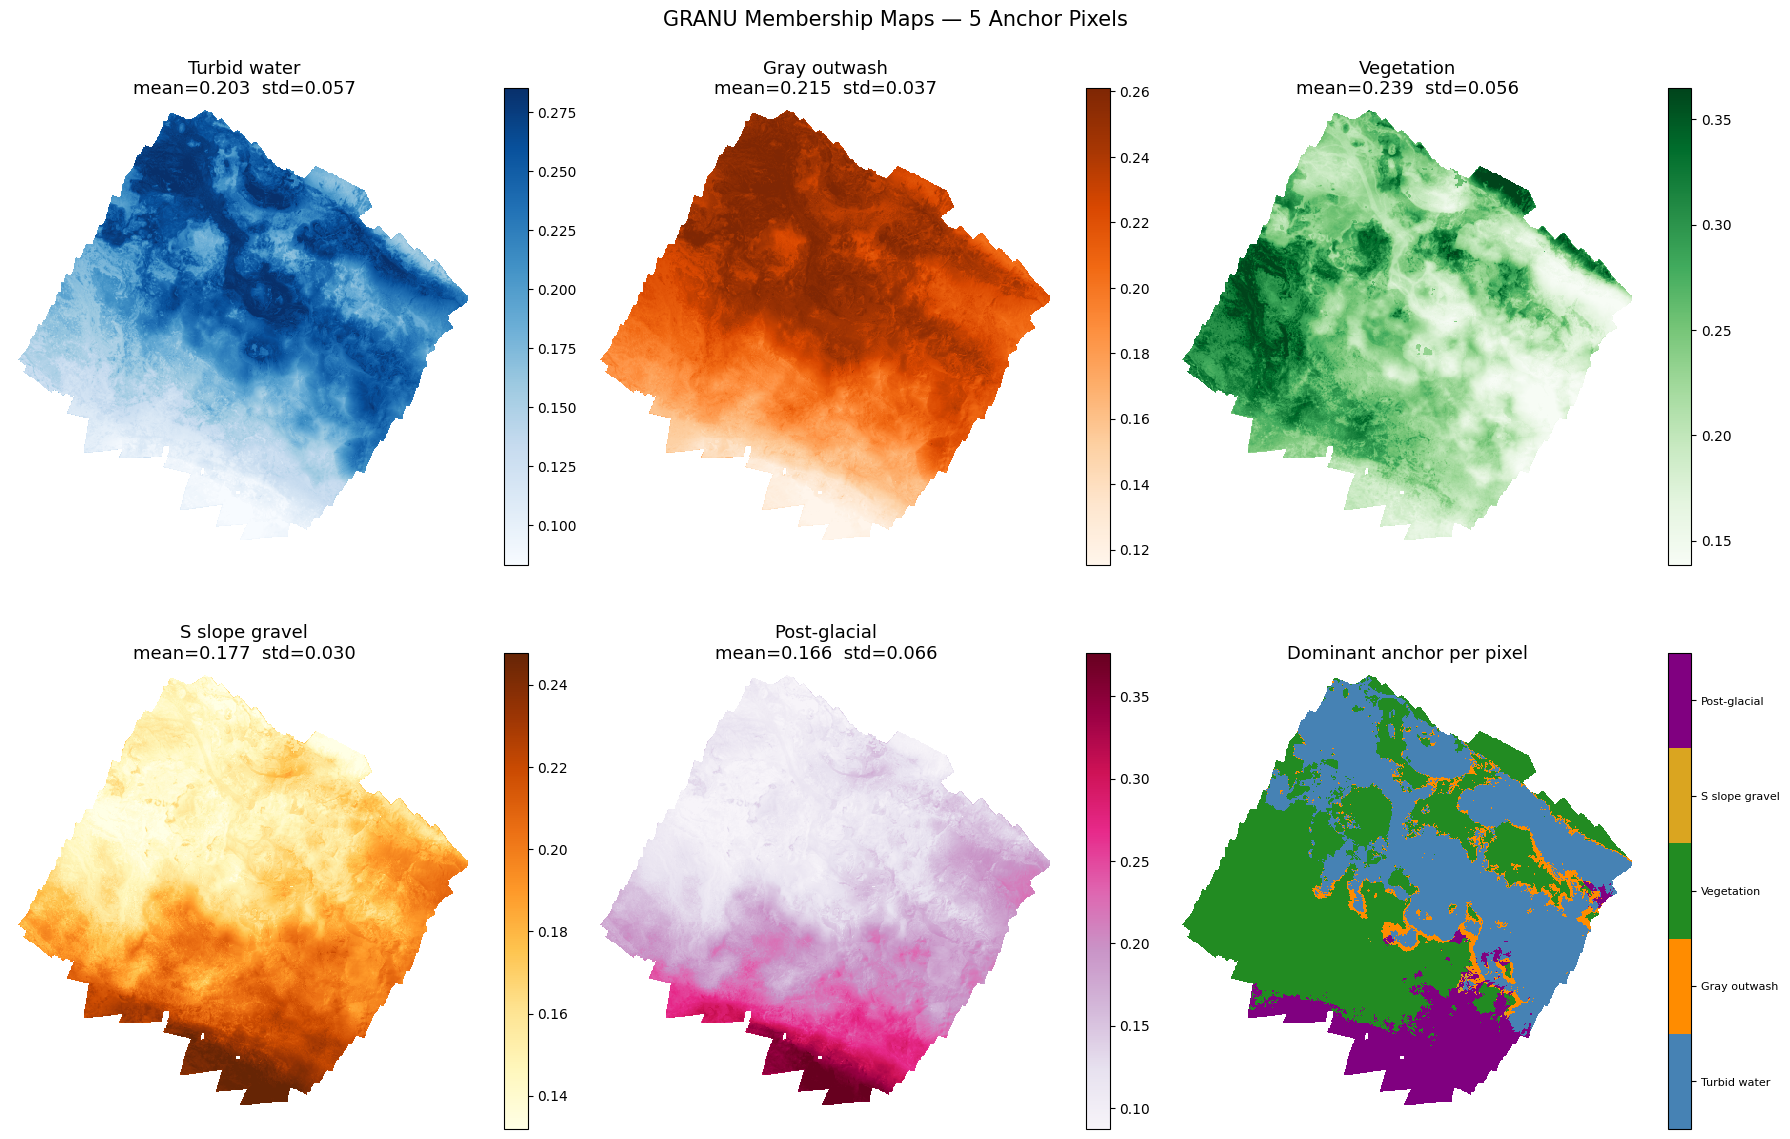

Saved granu_membership_maps2.png


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

cmaps = ['Blues', 'Oranges', 'Greens', 'YlOrBr', 'PuRd']

for i, (name, cmap) in enumerate(zip(anchor_names_short, cmaps)):
    canvas = np.full((NROWS, NCOLS), np.nan)
    canvas[valid_r, valid_c] = A_np[:, i]

    vmin = np.nanpercentile(canvas, 1)
    vmax = np.nanpercentile(canvas, 99)

    im = axes[i].imshow(canvas, cmap=cmap, vmin=vmin, vmax=vmax,
                        interpolation='nearest')
    axes[i].set_title(f'{name}\nmean={A_np[:,i].mean():.3f}  '
                      f'std={A_np[:,i].std():.3f}',
                      fontsize=13)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

# Dominant anchor map -- which anchor has highest membership per pixel
dominant = np.argmax(A_np, axis=1)
dom_canvas = np.full((NROWS, NCOLS), np.nan)
dom_canvas[valid_r, valid_c] = dominant

from matplotlib.colors import ListedColormap
dom_cmap = ListedColormap(['steelblue', 'darkorange',
                           'forestgreen', 'goldenrod', 'purple'])
im = axes[5].imshow(dom_canvas, cmap=dom_cmap,
                    vmin=-0.5, vmax=4.5,
                    interpolation='nearest')
axes[5].set_title('Dominant anchor per pixel', fontsize=13)
axes[5].axis('off')
cbar = plt.colorbar(im, ax=axes[5], fraction=0.046,
                    ticks=[0,1,2,3,4])
cbar.ax.set_yticklabels(anchor_names_short, fontsize=8)

plt.suptitle('GRANU Membership Maps — 5 Anchor Pixels', fontsize=15)
plt.tight_layout()
plt.savefig('granu_membership_maps2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved granu_membership_maps2.png')

In [34]:
# Recalibrate with stronger spatial emphasis
# Keep recon as anchor, push spatial terms to 3-4x current influence

LAM_ELEV   = 20.0    # up from 7.0
LAM_ASPECT = 25.0    # up from 7.5 -- aspect is the key differentiator
LAM_DDEM   = 15.0    # up from 6.5
LAM_BAND   = 0.02    # unchanged

In [35]:
# Fresh model
model = GRANU(D_s=7, D_t=5, D_out=32, R=8, D_attn=16, k=5).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
history = {'total': [], 'recon': [], 'spatial': [], 'band': []}